In [1]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device.rp_125_14_z7010 import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame
from redpitaya_io_sync.io.sync import TriggerSource
from redpitaya_io_sync.io.scope import ScopeSource

### Device instances

In [2]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

### IO Sequences & IO Frames instances

In [3]:
seq = IoSequence(device_list=[rp_0])
fr_0 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_1 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)

### Frame definitions 


In [4]:
#FRAME O (digital io latency)
fr_0.reset()
fr_0.digital_io_1.tristate(0x0)
fr_0.digital_io_1.output(0x0)
fr_0.scope_1.source(ScopeSource.DIGITAL_IO_1)
fr_0.delay(100)
fr_0.rsync()
fr_0.scope_1.acquire(16, label="dig_io")
fr_0.delay(2)
fr_0.digital_io_1.output(0x1)
fr_0.delay(100)


#analog output
fr_1.reset()
fr_1.scope_1.source(ScopeSource.RF_OUT_1)
fr_1.rf_out_1.amplitude(0)
fr_1.rf_out_1.frequency(0)
fr_1.rf_out_1.phase(0)
fr_1.rf_out_1.phase_reset()
fr_1.delay(100)
fr_1.rsync()
fr_1.scope_1.acquire(16, label="rf_out_amplitude")
fr_1.delay(2)
fr_1.rf_out_1.amplitude(1)
fr_1.delay(100)
fr_1.rsync()
fr_1.scope_1.acquire(16, label="rf_out_phase")
fr_1.delay(2)
fr_1.rf_out_1.phase(90)
fr_1.delay(100)
fr_1.rsync()
fr_1.scope_1.acquire(16, label="rf_out_frequency")
fr_1.delay(2)
fr_1.rf_out_1.frequency(125e6 / 16)
fr_1.delay(100)





### Sequence definition

In [5]:
seq.reset()
seq.add_frame(frame=fr_0, device=rp_0, label="dig_io_latency")
seq.add_frame(frame=fr_1, device=rp_0, label="rf_out_latency")
print(seq.sequence_description())

+--------------------+
| rp_0@192.168.1.143 |
+--------------------+
| dig_io_latency     |
| rf_out_latency     |
+--------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Upload & Run sequence

In [6]:
seq.upload(force=False)
seq.start()
while not seq.is_done():
    if seq.is_error():
        print("Sequence error. Please check status.")
        break
    time.sleep(0.01)


In [7]:
seq.get_status()

{'rp_0@192.168.1.143': {'enabled': True,
  'done': True,
  'error': False,
  'current_frame': 'rf_out_latency',
  'io': {'rf_out_1': {'error': False, 'done': True},
   'rf_out_2': {'error': False, 'done': True},
   'digital_io_1': {'error': False, 'done': True},
   'digital_io_2': {'error': False, 'done': True},
   'digital_io_3': {'error': False, 'done': True},
   'digital_io_4': {'error': False, 'done': True},
   'analog_out_1': {'error': False, 'done': True},
   'analog_out_2': {'error': False, 'done': True},
   'analog_out_3': {'error': False, 'done': True},
   'analog_out_4': {'error': False, 'done': True},
   'scope_1': {'error': False, 'done': True},
   'scope_2': {'error': False, 'done': True},
   'led': {'error': False, 'done': True}}}}

In [8]:
seq.stop()

### Plot acquisistions


Device: rp_0@192.168.1.143
Frame: dig_io_latency
Acquisition: dig_io (t=102, dec=1, samples=16)


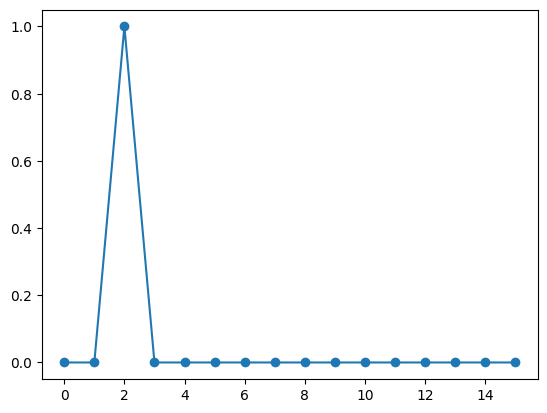

Device: rp_0@192.168.1.143
Frame: rf_out_latency
Acquisition: rf_out_amplitude (t=104, dec=1, samples=16)


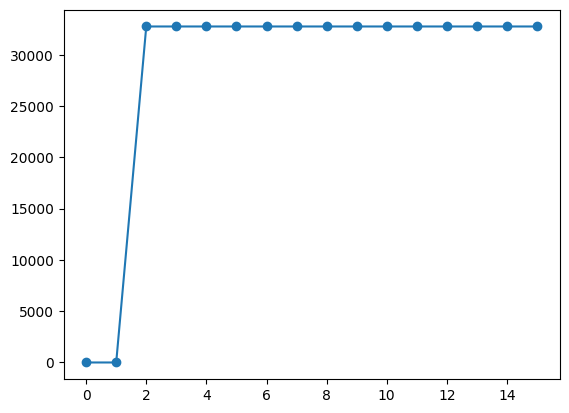

Device: rp_0@192.168.1.143
Frame: rf_out_latency
Acquisition: rf_out_phase (t=207, dec=1, samples=16)


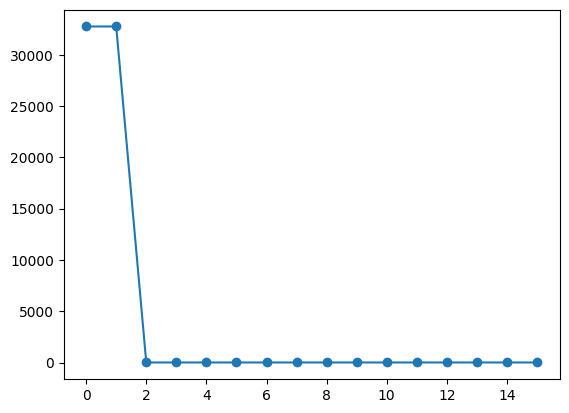

Device: rp_0@192.168.1.143
Frame: rf_out_latency
Acquisition: rf_out_frequency (t=310, dec=1, samples=16)


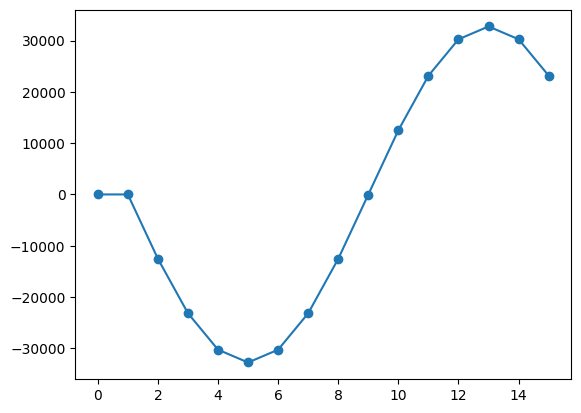

In [9]:
scope_dict = seq.get_scope()

for device_id in scope_dict.keys():
    for frame_label in scope_dict[device_id].keys():
        for scope_label in scope_dict[device_id][frame_label].keys():
            for acq_label in scope_dict[device_id][frame_label][scope_label].keys():
                t = scope_dict[device_id][frame_label][scope_label][acq_label]["t"]
                dec = scope_dict[device_id][frame_label][scope_label][acq_label]["dec"]
                samples = scope_dict[device_id][frame_label][scope_label][acq_label]["samples"]
                data = scope_dict[device_id][frame_label][scope_label][acq_label]["data"]
                print(f"Device: {device_id}")
                print(f"Frame: {frame_label}")
                print(f"Acquisition: {acq_label} (t={t}, dec={dec}, samples={samples})")
                plt.figure()
                plt.plot(data, "o-")
                plt.show()
    